In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
import librosa.display
from pydub import AudioSegment
from IPython.display import Audio

from src.helper import *

In [2]:
#set config
DATA_PATH = "data/deep-detect/dataset/"

### Checking dataset count and filetypes

Key takeaways : 

- Train files contain 76.9k audio files. 54.2% real and 45.8% fake.
- Train real samples are 100% .wav files, while the fake samples are 67.2% .mp3 and 32.8% .wav files.
- Need to be careful in feature extraction to make sure no bias exists between the two file types.
- Testing files contain 11.7k audio files. 59.6% real and 40.4% fake. 
- Testing files are 100% .wav files.
- Holdout files contain 14.4k .wav files.
- It seems like there are some distinct audio file sources shown by the prefix: file, itw, or train/dev_ami

In [3]:
folders_list = get_subfolders(DATA_PATH)
folders_list

['holdout',
 'testing',
 'testing/fake',
 'testing/real',
 'training',
 'training/fake',
 'training/real']

In [4]:
for folder in folders_list:
    path = os.path.join(DATA_PATH, folder)
    if not os.path.isdir(path):
        print(f"⚠️  Folder not found: {folder}")
        continue

    count, prefix_counter, ext_counter = get_file_stats(path)

    print(f"\n📂 Folder: {folder}. Total files: {count}.")
    prefix_str = [f"{num} x {prefix}" for prefix, num in prefix_counter.items()]
    print(f"Prefixes : {', '.join(prefix_str)}")
    ext_str = [f"{num} x {ext}" for ext, num in ext_counter.items()]
    print(f"Extensions : {', '.join(ext_str)}")


📂 Folder: holdout. Total files: 14397.
Prefixes : 14397 x audio_
Extensions : 14397 x wav

📂 Folder: testing. Total files: 11710.
Prefixes : 4634 x file, 6355 x itw, 243 x train_ami_isc_h_mie__, 85 x dev_ami_isb_h_mio__, 123 x dev_ami_isb_h_fie__, 141 x eval_ami_isb_h_fio__, 58 x eval_ami_isb_sdm_fie__, 46 x dev_ami_isb_h_mie__, 25 x train_ami_isc_h_mio__
Extensions : 11710 x wav

📂 Folder: testing/fake. Total files: 4733.
Prefixes : 2370 x file, 2363 x itw
Extensions : 4733 x wav

📂 Folder: testing/real. Total files: 6977.
Prefixes : 2264 x file, 3992 x itw, 243 x train_ami_isc_h_mie__, 85 x dev_ami_isb_h_mio__, 123 x dev_ami_isb_h_fie__, 141 x eval_ami_isb_h_fio__, 58 x eval_ami_isb_sdm_fie__, 46 x dev_ami_isb_h_mie__, 25 x train_ami_isc_h_mio__
Extensions : 6977 x wav

📂 Folder: training. Total files: 76943.
Prefixes : 53882 x file, 22245 x itw, 244 x dev_ami_ib_h_mio__, 309 x dev_ami_ib_sdm_mio__, 195 x dev_ami_ib_h_fie__, 68 x dev_ami_ib_h_fio__
Extensions : 23678 x mp3, 53265 x 

### Looking at sample audio files

Key takeaways : 
- Audio samples seem to consist of a few seconds of spoken words

In [5]:
sample_wav = os.path.join(DATA_PATH, "training/real/dev_ami_ib4001_h01_fie038_0000919_0001249.wav")
sample_mp3 = os.path.join(DATA_PATH, "training/fake/file3.mp3")

audio_samples = [sample_wav, sample_mp3]

Loaded data/deep-detect/dataset/training/real/dev_ami_ib4001_h01_fie038_0000919_0001249.wav
Sample rate: 16000
Duration: 3.30 seconds
Shape of waveform: (52800,)


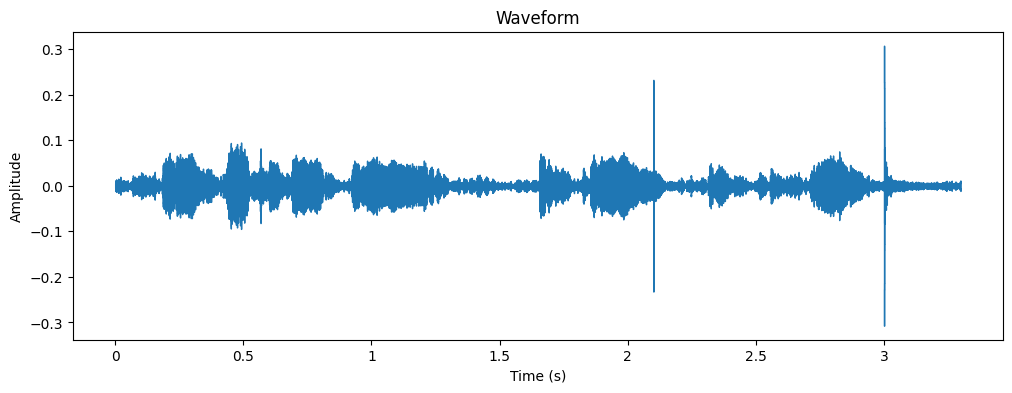

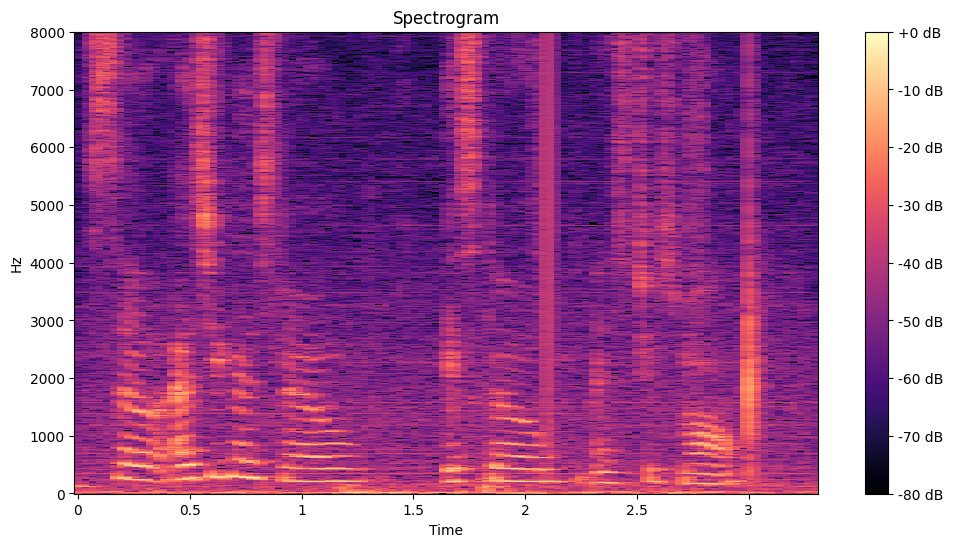

Channels: 1
Frame rate: 16000
Sample width: 4
Length (ms): 3300
Loaded data/deep-detect/dataset/training/fake/file3.mp3
Sample rate: 22050
Duration: 1.59 seconds
Shape of waveform: (35136,)


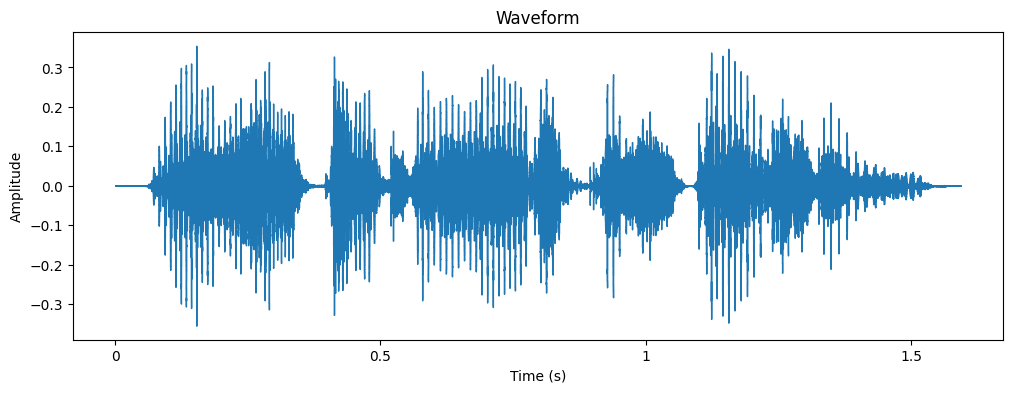

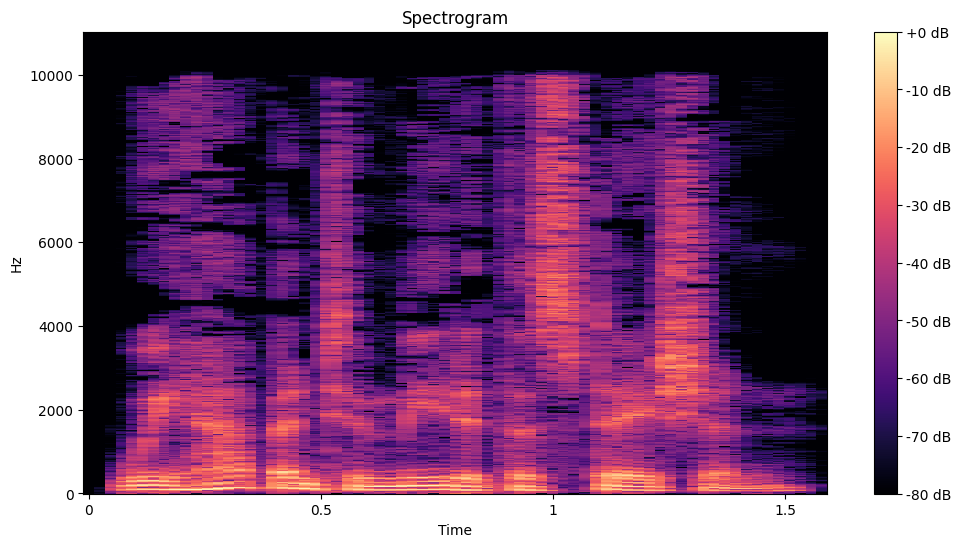

Channels: 1
Frame rate: 22050
Sample width: 2
Length (ms): 1593


In [6]:
for sample in audio_samples:
    # ---------- LOAD AUDIO ----------
    print('='*100)
    y, sr = librosa.load(sample, sr=None)  # waveform and sample rate
    print(f"Loaded {sample}")
    print(f"Sample rate: {sr}")
    print(f"Duration: {len(y)/sr:.2f} seconds")
    print(f"Shape of waveform: {y.shape}")

    # ---------- VISUALIZE WAVEFORM ----------
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title("Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

    # ---------- SPECTROGRAM ----------
    D = np.abs(librosa.stft(y))
    DB = librosa.amplitude_to_db(D, ref=np.max)

    plt.figure(figsize=(12, 6))
    librosa.display.specshow(DB, sr=sr, x_axis="time", y_axis="hz")
    plt.colorbar(format="%+2.0f dB")
    plt.title("Spectrogram")
    plt.show()

    # ---------- METADATA (with pydub) ----------
    audio = AudioSegment.from_file(sample)
    print(f"Channels: {audio.channels}")
    print(f"Frame rate: {audio.frame_rate}")
    print(f"Sample width: {audio.sample_width}")
    print(f"Length (ms): {len(audio)}")

In [7]:
# ---------- PLAY AUDIO ----------
Audio(sample_wav)  # plays the file

In [8]:
# ---------- PLAY AUDIO ----------
Audio(sample_mp3)  # plays the file

### Checking audio feature distributions of train and test

Key takeaways : 

- Some training files that are labeled fake is failed to be read by librosa

In [9]:
# ---------- COLLECT FILES ----------
records = []

for split in ["testing", "training"]:
    for label in ["real", "fake"]:
        folder = os.path.join(DATA_PATH, split, label)
        if not os.path.exists(folder):
            continue
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            if os.path.isfile(fpath):
                name, ext = os.path.splitext(fpath)
                prefix = ''.join(ch for ch in name if not ch.isdigit())
                ext = ext.lower().lstrip(".")
                
                features = extract_audio_features(fpath)
                
                record = {
                    "filepath": fpath,
                    "filename": fname,
                    "extension": ext,
                    "prefix": prefix,
                    "split": split,
                    "label": label
                }
                record.update(features)
                records.append(record)

# ---------- TO DATAFRAME ----------
df = pd.DataFrame(records)

# ---------- SUMMARY ----------
print(df.head())
print(f"\nTotal files: {len(df)}")
print(df.groupby(["split", "label"]).size())

Note: Illegal Audio-MPEG-Header 0x00000000 at offset 50.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
/home/ardacandra/Documents/Repos/deepdetect_audio_deepfake_detection_challenge/src/helper.py:43: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(filepath, sr=None)  # keep original sample rate
/home/ardacandra/miniconda3/envs/deepdetect_audio_deepfake_detection_challenge/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error loading data/deep-detect/dataset/training/fake/file16643.mp3: 


/home/ardacandra/Documents/Repos/deepdetect_audio_deepfake_detection_challenge/src/helper.py:43: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(filepath, sr=None)  # keep original sample rate
/home/ardacandra/miniconda3/envs/deepdetect_audio_deepfake_detection_challenge/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error loading data/deep-detect/dataset/training/fake/file27839.mp3: 
Error loading data/deep-detect/dataset/training/fake/file32972.mp3: 


Note: Illegal Audio-MPEG-Header 0x00000000 at offset 50.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


...

Error loading data/deep-detect/dataset/training/fake/file9875.mp3: 
Error loading data/deep-detect/dataset/training/fake/file15746.mp3: 


Note: Illegal Audio-MPEG-Header 0x00000000 at offset 50.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Error loading data/deep-detect/dataset/training/fake/file31017.mp3: 


/home/ardacandra/Documents/Repos/deepdetect_audio_deepfake_detection_challenge/src/helper.py:43: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(filepath, sr=None)  # keep original sample rate
/home/ardacandra/miniconda3/envs/deepdetect_audio_deepfake_detection_challenge/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error loading data/deep-detect/dataset/training/fake/file17407.mp3: 
Error loading data/deep-detect/dataset/training/fake/file27206.mp3: 
Error loading data/deep-detect/dataset/training/fake/file27643.mp3: 
Error loading data/deep-detect/dataset/training/fake/file17450.mp3: 
Error loading data/deep-detect/dataset/training/fake/file5323.mp3: 
Error loading data/deep-detect/dataset/training/fake/file13424.mp3: 
Error loading data/deep-detect/dataset/training/fake/file30959.mp3: 
                                            filepath      filename extension  \
0  data/deep-detect/dataset/testing/real/file542.wav   file542.wav       wav   
1  data/deep-detect/dataset/testing/real/file671.wav   file671.wav       wav   
2   data/deep-detect/dataset/testing/real/itw735.wav    itw735.wav       wav   
3  data/deep-detect/dataset/testing/real/file1169...  file1169.wav       wav   
4  data/deep-detect/dataset/testing/real/itw18571...  itw18571.wav       wav   

                                     

In [ ]:
#fix prefix to exclude the folder paths
df['prefix'] = df['prefix'].apply(lambda x:x.split("/")[-1])

In [19]:
print(df.shape)
print(df.columns)
df.head(3)

(88653, 11)
Index(['filepath', 'filename', 'extension', 'prefix', 'split', 'label',
       'duration', 'sample_rate', 'rms_energy', 'zero_crossing_rate',
       'spectral_centroid'],
      dtype='object')


,filepath,filename,extension,prefix,split,label,duration,sample_rate,rms_energy,zero_crossing_rate,spectral_centroid
0,data/deep-detect/dataset/testing/real/file542.wav,file542.wav,wav,file,testing,real,3.375062,16000.0,0.078996,0.123070,1678.634801
1,data/deep-detect/dataset/testing/real/file671.wav,file671.wav,wav,file,testing,real,2.095063,16000.0,0.103099,0.150442,1928.962536
2,data/deep-detect/dataset/testing/real/itw735.wav,itw735.wav,wav,itw,testing,real,1.245062,16000.0,0.041119,0.059295,1039.774261


In [20]:
if not os.path.exists("output"):
    os.mkdir("output")

df.to_csv("output/nb_00__train_test_audio_feats.csv", index=False)